<a href="https://colab.research.google.com/github/yusuf-codes10/deep-learining-project/blob/main/cnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data init

In [ ]:
# STEP 1 — Set Kaggle credentials (run this first)
import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Enter Kaggle username: ")
os.environ['KAGGLE_API_TOKEN'] = getpass("Enter Kaggle API key: ")

Enter Kaggle username: youcefcopy
Enter Kaggle API key: ··········


In [ ]:
# STEP 2 — Install Kaggle (run once per session)
!pip install -q kaggle

In [ ]:
# STEP 3 — Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:31<00:00, 16.3MB/s]



In [ ]:
# STEP 4 — Unzip dataset
!unzip -q chest-xray-pneumonia.zip

# Data Augmantation & Normalization

## 1- Laoding all image (size 64x64)

In [ ]:
# ── Load all training images manually at 64x64 ──────────────────────────────
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator

def load_images_from_folder(folder, label, target_size=(64, 64)):
    images, labels = [], []
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            img = load_img(fpath, target_size=target_size)
            images.append(img_to_array(img) / 255.0)
            labels.append(label)
        except:
            pass
    return images, labels

normal_imgs, normal_labels       = load_images_from_folder("chest_xray/train/NORMAL",    0)
pneumonia_imgs, pneumonia_labels = load_images_from_folder("chest_xray/train/PNEUMONIA", 1)

print(f"NORMAL:    {len(normal_imgs)}")
print(f"PNEUMONIA: {len(pneumonia_imgs)}")

NORMAL:    1341
PNEUMONIA: 3875


## Data Augmentation (filling the normal class imbalance)

In [ ]:
# ── Augment NORMAL only until it matches PNEUMONIA count ────────────────────
aug = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

normal_imgs_aug    = list(normal_imgs)
normal_labels_aug  = list(normal_labels)
target_count       = len(pneumonia_imgs)
normal_array       = np.array(normal_imgs)

while len(normal_imgs_aug) < target_count:
    idx       = np.random.randint(0, len(normal_imgs))
    src       = normal_array[idx].reshape(1, 64, 64, 3)
    augmented = next(aug.flow(src, batch_size=1))[0]
    normal_imgs_aug.append(augmented)
    normal_labels_aug.append(0)

print(f"NORMAL after oversampling: {len(normal_imgs_aug)}")
print(f"PNEUMONIA:                 {len(pneumonia_imgs)}")

NORMAL after oversampling: 3875
PNEUMONIA:                 3875


## 3- Shuffling

In [ ]:
# ── Combine + shuffle ────────────────────────────────────────────────────────
X = np.array(normal_imgs_aug + pneumonia_imgs)
y = np.array(normal_labels_aug + pneumonia_labels)

idx  = np.random.permutation(len(X))
X, y = X[idx], y[idx]

print(f"Final dataset: {X.shape}")
print(f"NORMAL={sum(y==0)}, PNEUMONIA={sum(y==1)}")

Final dataset: (7750, 64, 64, 3)
NORMAL=3875, PNEUMONIA=3875


In [ ]:
# ── Train/val split ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")

Train: (6200, 64, 64, 3) | Val: (1550, 64, 64, 3)


# CNN Training

## 1- Model Archetcture

In [ ]:
# ── Build CNN v3 ─────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers

l2 = regularizers.l2(0.001)

cnn_v3 = keras.models.Sequential([

    # Block 1
    keras.layers.Conv2D(32, 3, activation='relu', padding='same',
                        kernel_regularizer=l2, input_shape=(64, 64, 3)),
    keras.layers.Conv2D(32, 3, activation='relu', padding='same',
                        kernel_regularizer=l2),
    keras.layers.MaxPooling2D(2, 2),   # → 32x32

    # Block 2
    keras.layers.Conv2D(64, 3, activation='relu', padding='same',
                        kernel_regularizer=l2),
    keras.layers.Conv2D(64, 3, activation='relu', padding='same',
                        kernel_regularizer=l2),
    keras.layers.MaxPooling2D(2, 2),   # → 16x16

    # Block 3
    keras.layers.Conv2D(128, 3, activation='relu', padding='same',
                        kernel_regularizer=l2),
    keras.layers.Conv2D(128, 3, activation='relu', padding='same',
                        kernel_regularizer=l2),
    keras.layers.MaxPooling2D(2, 2),   # → 8x8

    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=l2),
    keras.layers.Dense(1, activation='sigmoid')
], name='cnn_v3')

cnn_v3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,384,673 (9.10 MB)

 Trainable params: 2,384,673 (9.10 MB)

 Non-trainable params: 0 (0.00 B)

## 2- Compiling

In [ ]:
cnn_v3.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## 3- Fitting (no early stopping)

In [ ]:
# ── Train ────────────────────────────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

cnn_v3_history = cnn_v3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    # callbacks=[early_stop]
    # ❗ no class_weight — data is already balanced
)

Epoch 1/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.8187 - loss: 0.5105 - val_accuracy: 0.9026 - val_loss: 0.3754
Epoch 2/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9334 - loss: 0.2283 - val_accuracy: 0.9581 - val_loss: 0.1678
Epoch 3/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9476 - loss: 0.1842 - val_accuracy: 0.9652 - val_loss: 0.1482
Epoch 4/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9498 - loss: 0.1892 - val_accuracy: 0.9606 - val_loss: 0.1529
Epoch 5/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9597 - loss: 0.1579 - val_accuracy: 0.9523 - val_loss: 0.1889
Epoch 6/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9598 - loss: 0.1507 - val_accuracy: 0.9716 - val_loss: 0.1255
Epoch 7/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9613 - loss: 0.1439 - val_accuracy: 0.9684 - val_loss: 0.1347
Epoch 8/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9677 - loss: 0.1334 - val_acc

## 4- Test and Evalution

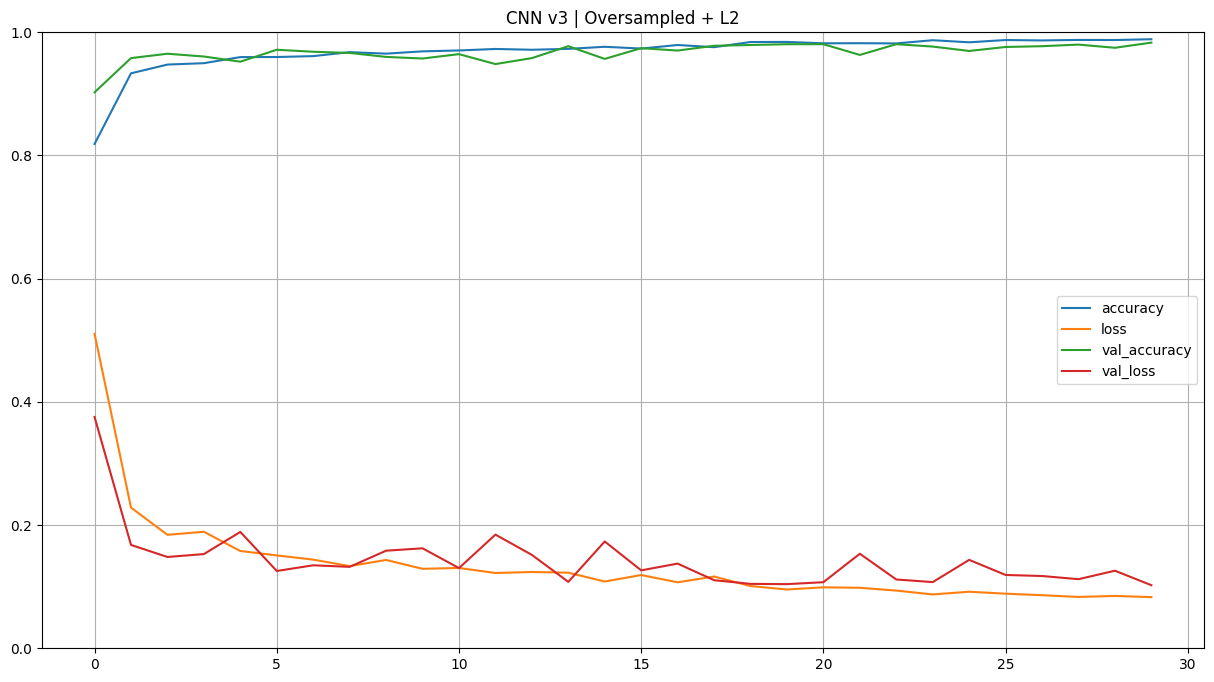

In [ ]:
# ── Graph ────────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(cnn_v3_history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title('CNN v3 | Oversampled + L2')
plt.show()

**Note**
The model is looking pretty good, no overfitting

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step
              precision    recall  f1-score   support

      NORMAL       0.94      0.65      0.77       234
   PNEUMONIA       0.82      0.98      0.89       390

    accuracy                           0.86       624
   macro avg       0.88      0.82      0.83       624
weighted avg       0.87      0.86      0.85       624



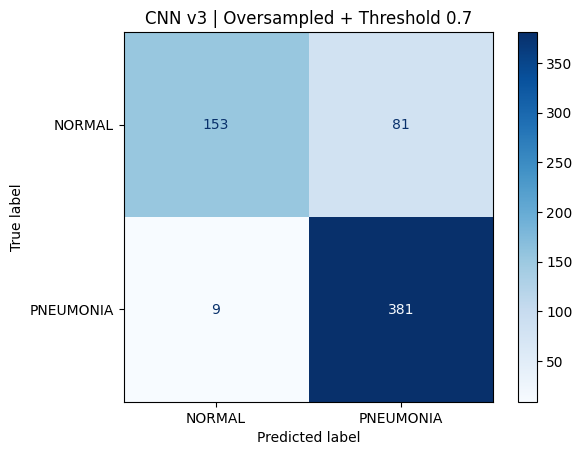

In [ ]:
# ── Evaluation with threshold 0.7 ────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# need test images as numpy array too
test_imgs, test_labels = load_images_from_folder("chest_xray/test/NORMAL",    0, target_size=(64,64))
test_imgs2, test_labels2 = load_images_from_folder("chest_xray/test/PNEUMONIA", 1, target_size=(64,64))

X_test = np.array(test_imgs + test_imgs2)
y_test = np.array(test_labels + test_labels2)

cnn_v3_preds     = cnn_v3.predict(X_test)
predicted_v3     = (cnn_v3_preds > 0.7).astype(int).flatten()  # 🔥 threshold 0.7

print(classification_report(y_test, predicted_v3, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(y_test, predicted_v3)
ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'PNEUMONIA']).plot(cmap='Blues')
plt.title('CNN v3 | Oversampled + Threshold 0.7')
plt.show()

**Really good confusion matrix**

In [ ]:
# ── Save ─────────────────────────────────────────────────────────────────────
cnn_v3.save('/content/drive/MyDrive/pneum-project/cnn_v3.h5')
print("Saved!")

Saved!


In [ ]:
# make sure the folder exists
import os

os.makedirs('/content/drive/MyDrive/pneum-project', exist_ok=True)

In [ ]:
# verify it was saved correctly
!ls /content/drive/MyDrive/pneum-project

cnn_v3.h5
